<a href="https://colab.research.google.com/github/caleb-cramer/Dueling-Bandits-for-ATP-Tennis/blob/main/541_FinalProject_TennisSeq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup, Variables, and Data Processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

arms_1 = 20
arms_2 = 23

dtype_dict = {
    'Tournament': "string", 'Series': "string", 'Court': "string", 'Surface': "string",
    'Round': "string", 'Best of': "Int64", 'Player_1': "string", 'Player_2': "string",
    'Winner': "string", 'Rank_1': "Int64", 'Rank_2': "Int64", 'Pts_1': "Int64",
    'Pts_2': "Int64", 'Odd_1': "float64", 'Odd_2': "float64", 'Score': "string"
}

raw_data = pd.read_csv('atp_tennis.csv', dtype=dtype_dict, parse_dates=['Date'], na_values=['-'])
raw_data.drop(raw_data[(raw_data['Rank_1'] == -1.0) | (raw_data['Rank_2'] == -1.0)].index, inplace=True)
raw_data.dropna(axis=0, inplace=True)

date_filtered = raw_data[(raw_data['Date'] >= '2004-12-30') & (raw_data['Date'] <= '2026-12-30')]
player1_counts = date_filtered['Player_1'].value_counts()
player2_counts = date_filtered['Player_2'].value_counts()

total_matches_played = player1_counts.add(player2_counts, fill_value=0).astype('Int64').sort_values(ascending=False)

next_gen = ['Dimitrov G.','Kyrgios N.', 'Tsitsipas S.', 'Medvedev D.']
top20 = total_matches_played.head(arms_1).index.tolist()
allPlayers = top20 + next_gen[:arms_2-arms_1]
print("Players Pool:", allPlayers)

condition_dates = (raw_data['Date'] >= '2004-12-30') & (raw_data['Date'] <= '2026-12-30')
condition_t20players = (raw_data['Player_1'].isin(top20)) & (raw_data['Player_2'].isin(top20))
condition_allplayers = (raw_data['Player_1'].isin(allPlayers)) & (raw_data['Player_2'].isin(allPlayers))
condition_surfaces = (raw_data['Surface'] == 'Hard') | (raw_data['Surface'] == 'Clay') | (raw_data['Surface'] == 'Grass')

top20_matchups = raw_data[condition_dates & condition_t20players & condition_surfaces].reset_index(drop=True)
allPlayers_matchups = raw_data[condition_dates & condition_allplayers & condition_surfaces].reset_index(drop=True)

Players Pool: ['Djokovic N.', 'Nadal R.', 'Federer R.', 'Murray A.', 'Ferrer D.', 'Gasquet R.', 'Verdasco F.', 'Wawrinka S.', 'Cilic M.', 'Monfils G.', 'Berdych T.', 'Simon G.', 'Lopez F.', 'Fognini F.', 'Kohlschreiber P.', 'Isner J.', 'Dimitrov G.', 'Seppi A.', 'Zverev A.', 'Querrey S.', 'Dimitrov G.', 'Kyrgios N.', 'Tsitsipas S.']


## Chronological Match Environment

In [2]:
class TennisEnvironment:
    def __init__(self, df, players, surface):
        self.players = players
        self.surface = surface
        self.df = df[df['Surface'] == surface].sort_values('Date').reset_index(drop=True)

        self.match_queues = {}
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                p1, p2 = players[i], players[j]
                pair_matches = self.df[((self.df['Player_1'] == p1) & (self.df['Player_2'] == p2)) |
                                       ((self.df['Player_1'] == p2) & (self.df['Player_2'] == p1))]
                pair_key = tuple(sorted([p1, p2]))
                self.match_queues[pair_key] = pair_matches.to_dict('records')

        self.current_ranks = {p: 50.0 for p in players}
        for p in players:
            p_matches = self.df[(self.df['Player_1'] == p) | (self.df['Player_2'] == p)]
            if not p_matches.empty:
                first_match = p_matches.iloc[0]
                self.current_ranks[p] = first_match['Rank_1'] if first_match['Player_1'] == p else first_match['Rank_2']

        # --- NEW: STAT TRACKERS ---
        self.surface_matches = {p: 0 for p in players}
        self.surface_wins = {p: 0.0 for p in players}
        self.recent_form = {p: [] for p in players} # Will hold a rolling list of 1s (wins) and 0s (losses)

    def get_context(self):
        surface_win_rates = []
        recent_form_rates = []

        for p in self.players:
            # Calculate rolling surface win rate (default to 0.5 if no matches played yet)
            if self.surface_matches[p] > 0:
                surface_win_rates.append(self.surface_wins[p] / self.surface_matches[p])
            else:
                surface_win_rates.append(0.5)

            # Calculate recent form over the last 10 matches (default to 0.5)
            if len(self.recent_form[p]) > 0:
                recent_form_rates.append(sum(self.recent_form[p]) / len(self.recent_form[p]))
            else:
                recent_form_rates.append(0.5)

        return {
            'ranks': [self.current_ranks[p] for p in self.players],
            'surface_win_rates': surface_win_rates,
            'recent_form_rates': recent_form_rates,
            'best_of': 3
        }

    def duel(self, player_a, player_b):
        pair_key = tuple(sorted([player_a, player_b]))
        queue = self.match_queues.get(pair_key, [])

        if not queue:
            return 0.5

        match = queue.pop(0)

        # Update Ranks
        if match['Player_1'] == player_a:
            self.current_ranks[player_a] = match['Rank_1']
            self.current_ranks[player_b] = match['Rank_2']
        else:
            self.current_ranks[player_a] = match['Rank_2']
            self.current_ranks[player_b] = match['Rank_1']

        # --- NEW: UPDATE STAT TRACKERS ---
        winner = match['Winner']
        is_a_winner = 1.0 if winner == player_a else 0.0
        is_b_winner = 1.0 - is_a_winner

        # Player A Updates
        self.surface_matches[player_a] += 1
        self.surface_wins[player_a] += is_a_winner
        self.recent_form[player_a].append(is_a_winner)
        if len(self.recent_form[player_a]) > 10:
            self.recent_form[player_a].pop(0) # Keep queue at max length of 10

        # Player B Updates
        self.surface_matches[player_b] += 1
        self.surface_wins[player_b] += is_b_winner
        self.recent_form[player_b].append(is_b_winner)
        if len(self.recent_form[player_b]) > 10:
            self.recent_form[player_b].pop(0)

        return is_a_winner

## Condorcet & Borda Score Helpers

In [3]:
def analyze_condorcet_by_surface(df):
    surfaces = df['Surface'].unique()
    results = {}
    for surface in surfaces:
        s_df = df[df['Surface'] == surface]
        players = sorted(list(set(s_df['Player_1']).union(set(s_df['Player_2']))))
        matrix = pd.DataFrame(0.0, index=players, columns=players)
        match_counts = pd.DataFrame(0, index=players, columns=players)
        for _, row in s_df.iterrows():
            w, p1, p2 = row['Winner'], row['Player_1'], row['Player_2']
            l = p1 if w == p2 else p2
            matrix.at[w, l] += 1
            match_counts.at[p1, p2] += 1
            match_counts.at[p2, p1] += 1
        prob_matrix = matrix.copy()
        for i in players:
            for j in players:
                if match_counts.at[i, j] > 0:
                    prob_matrix.at[i, j] = matrix.at[i, j] / match_counts.at[i, j]
        winner = None
        for i in players:
            if all(matrix.at[i, j] > matrix.at[j, i] for j in players if i != j and match_counts.at[i, j] > 0):
                winner = i
                break
        results[surface] = {'winner': winner, 'matrix': prob_matrix}
    return results

def calculate_and_print_borda(surface_results, group_name="Players"):
    borda_scores_dict = {}
    for surface, data in surface_results.items():
        matrix = data['matrix']
        scores = matrix.sum(axis=1).sort_values(ascending=False)
        borda_scores_dict[surface] = scores
    return borda_scores_dict

def print_top_k(scores, players, title, k=3):
    ranking = np.argsort(scores)[::-1]
    print(f"\n{title}:")
    for rank in range(k):
        idx = ranking[rank]
        print(f"{rank+1}. {players[idx]} (Win Prob: {scores[idx]:.4f})")

## Bandits! Helper Functions

In [13]:
def borda_UCB_dynamic(env, T, T_1, initial_k, true_borda_scores, explore_param=1.414):
    players = env.players
    n_arms = len(players)
    counts = np.zeros(n_arms)
    rewards = np.zeros(n_arms)
    b_hat = np.zeros(n_arms)
    regrets = np.zeros(T)

    for t in range(T):
        current_k = initial_k if t < T_1 else n_arms
        active_arms = list(range(current_k))

        unplayed = [i for i in active_arms if counts[i] == 0]
        if len(unplayed) > 0:
            i_t = unplayed[0]
        else:
            total_pulls = np.sum(counts[:current_k])
            ucb_scores = b_hat[:current_k] + explore_param * np.sqrt(np.log(total_pulls) / counts[:current_k])
            i_t = np.argmax(ucb_scores)

        possible_opponents = [j for j in active_arms if j != i_t]
        j_t = np.random.choice(possible_opponents)

        reward = env.duel(players[i_t], players[j_t])

        counts[i_t] += 1
        rewards[i_t] += reward
        b_hat[i_t] = rewards[i_t] / counts[i_t]

        optimal_borda = np.max(true_borda_scores[:current_k])
        instantaneous_regret = optimal_borda - true_borda_scores[i_t]
        regrets[t] = instantaneous_regret if t == 0 else regrets[t-1] + instantaneous_regret

    return regrets, b_hat

def build_pairwise_phi(context, i, j):
    # 1. Rank Context
    rank_i = context['ranks'][i]
    rank_j = context['ranks'][j]
    rank_diff = (rank_i - rank_j) / 200.0

    # 2. Tournament Context
    is_bo5 = 1.0 if context['best_of'] == 5 else 0.0
    bo5_rank_interaction = rank_diff * is_bo5

    # 3. Surface Mastery Context (NEW)
    # Positive value means Player I has a better win rate than Player J
    win_rate_diff = context['surface_win_rates'][i] - context['surface_win_rates'][j]

    # 4. Recent Form Context (NEW)
    # Positive value means Player I is hotter in their last 10 matches
    form_diff = context['recent_form_rates'][i] - context['recent_form_rates'][j]

    # Array length is now 4 instead of 2
    return np.array([rank_diff, bo5_rank_interaction, win_rate_diff, form_diff])

def run_pairwise_linucb_dynamic(env, true_borda_scores, num_actions, T, T_1, initial_k, feature_dim, explore_param=0.1):
    A_initial = np.eye(feature_dim)*0.1
    A_inv = np.linalg.inv(A_initial)
    b = np.zeros(feature_dim)
    cumulative_regret = np.zeros(T)

    for t in range(T):
        current_k = initial_k if t < T_1 else num_actions

        # Query the environment for the current ranks BEFORE the match happens
        c_t = env.get_context()

        theta_hat = A_inv @ b
        borda_ucb_scores = np.zeros(current_k)

        for i in range(current_k):
            ucb_sum = 0.0
            for j in range(current_k):
                if i == j: continue
                phi_ij = build_pairwise_phi(c_t, i, j)
                prediction = 0.5 + np.dot(phi_ij, theta_hat)
                uncertainty = np.dot(phi_ij, np.dot(A_inv, phi_ij))
                ucb_ij = prediction + explore_param * np.sqrt(uncertainty)
                ucb_sum += ucb_ij
            borda_ucb_scores[i] = ucb_sum / (current_k - 1)

        i_t = np.argmax(borda_ucb_scores)
        possible_opponents = [j for j in range(current_k) if j != i_t]
        j_t = np.random.choice(possible_opponents)

        # Execute the match and let the environment update the ranks for the NEXT loop
        r_t = env.duel(env.players[i_t], env.players[j_t])

        phi_played = build_pairwise_phi(c_t, i_t, j_t)
        phi_played_col = phi_played.reshape(-1, 1)

        centered_reward = r_t - 0.5
        b += centered_reward * phi_played

        u = phi_played_col
        Au = A_inv @ u
        denominator = 1.0 + u.T @ Au
        A_inv -= (Au @ Au.T) / denominator

        optimal_borda = np.max(true_borda_scores[:current_k])
        instantaneous_regret = optimal_borda - true_borda_scores[i_t]
        cumulative_regret[t] = instantaneous_regret if t == 0 else cumulative_regret[t-1] + instantaneous_regret

    return cumulative_regret, A_inv, b

## Multi-Surface Bandit Execution Loop


RUNNING CHRONOLOGICAL BANDIT SIMULATION FOR HARD COURT
Running Dynamic Borda-UCB for Hard...
Running Dynamic Pairwise LinUCB for Hard...


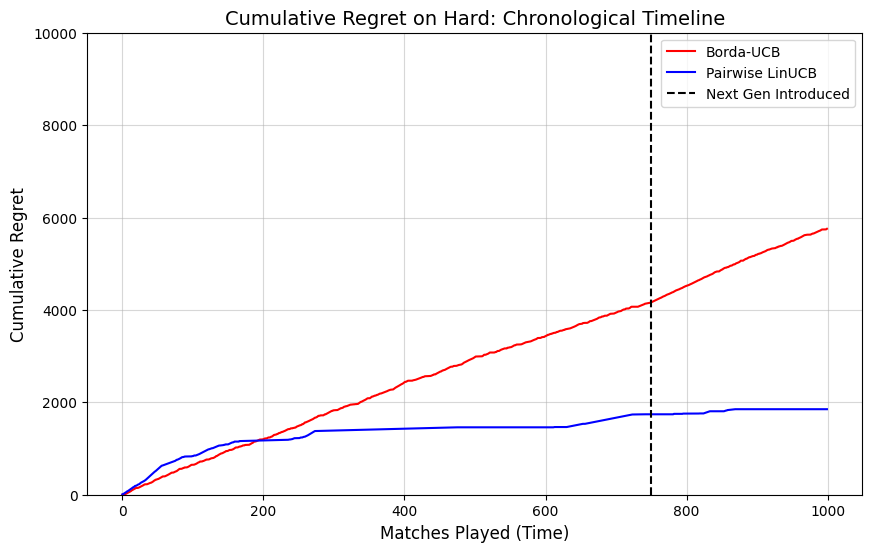


--- FINAL WIN PROBABILITIES FOR HARD COURT [0 to 1] ---

Borda-UCB Top Predicted Players:
1. Djokovic N. (Win Prob: 0.7576)
2. Federer R. (Win Prob: 0.7160)
3. Nadal R. (Win Prob: 0.7089)

Pairwise LinUCB Top Predicted Players:
1. Djokovic N. (Win Prob: 0.6702)
2. Kyrgios N. (Win Prob: 0.5953)
3. Cilic M. (Win Prob: 0.5628)

ACTUAL True Top Players (Ground Truth):
1. Djokovic N. (Win Prob: 0.7873)
2. Federer R. (Win Prob: 0.7687)
3. Nadal R. (Win Prob: 0.7013)

RUNNING CHRONOLOGICAL BANDIT SIMULATION FOR CLAY COURT
Running Dynamic Borda-UCB for Clay...
Running Dynamic Pairwise LinUCB for Clay...


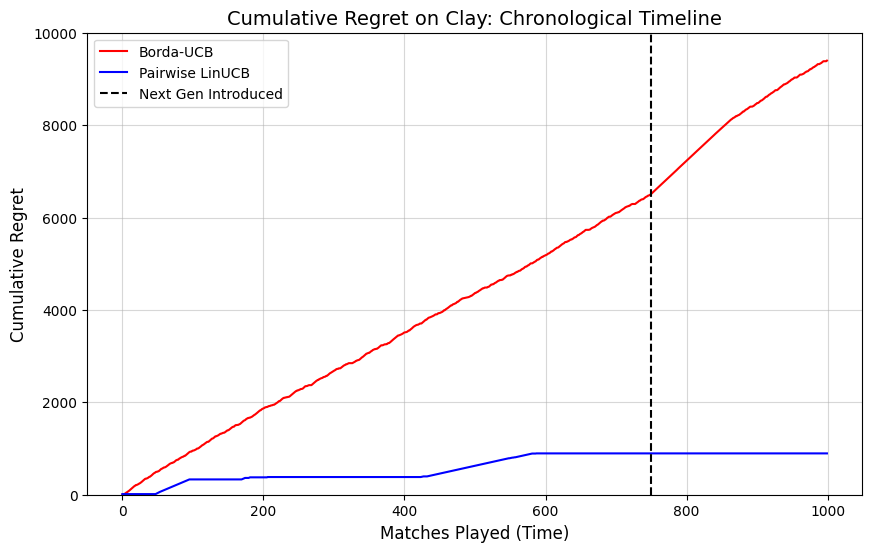


--- FINAL WIN PROBABILITIES FOR CLAY COURT [0 to 1] ---

Borda-UCB Top Predicted Players:
1. Nadal R. (Win Prob: 0.7773)
2. Djokovic N. (Win Prob: 0.6522)
3. Federer R. (Win Prob: 0.6167)

Pairwise LinUCB Top Predicted Players:
1. Nadal R. (Win Prob: 0.5748)
2. Djokovic N. (Win Prob: 0.5518)
3. Federer R. (Win Prob: 0.5363)

ACTUAL True Top Players (Ground Truth):
1. Nadal R. (Win Prob: 0.8678)
2. Djokovic N. (Win Prob: 0.7138)
3. Federer R. (Win Prob: 0.5744)

RUNNING CHRONOLOGICAL BANDIT SIMULATION FOR GRASS COURT
Running Dynamic Borda-UCB for Grass...
Running Dynamic Pairwise LinUCB for Grass...


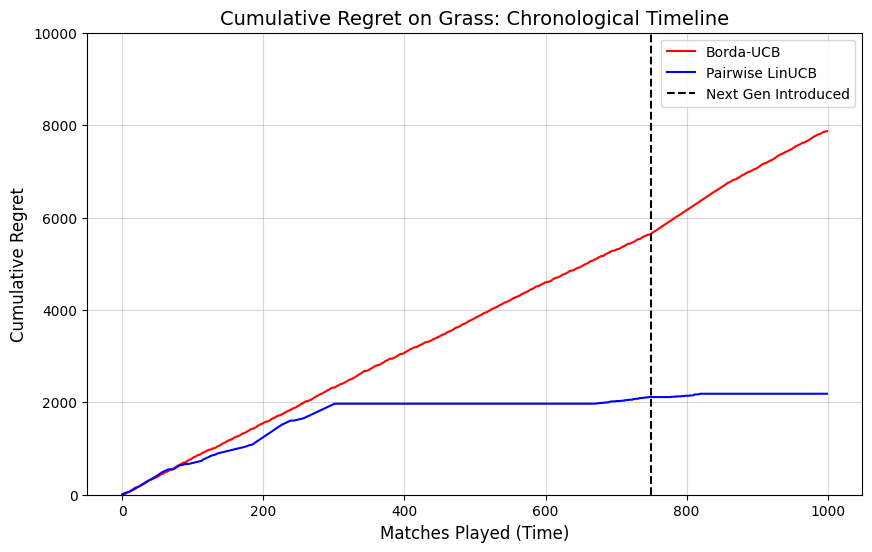


--- FINAL WIN PROBABILITIES FOR GRASS COURT [0 to 1] ---

Borda-UCB Top Predicted Players:
1. Federer R. (Win Prob: 0.5968)
2. Lopez F. (Win Prob: 0.5776)
3. Djokovic N. (Win Prob: 0.5636)

Pairwise LinUCB Top Predicted Players:
1. Federer R. (Win Prob: 0.5133)
2. Nadal R. (Win Prob: 0.5103)
3. Murray A. (Win Prob: 0.5099)

ACTUAL True Top Players (Ground Truth):
1. Federer R. (Win Prob: 0.6023)
2. Murray A. (Win Prob: 0.5682)
3. Djokovic N. (Win Prob: 0.4356)


In [14]:
surface_results_all = analyze_condorcet_by_surface(allPlayers_matchups)
borda_scores_by_surface_all = calculate_and_print_borda(surface_results_all, "All 23 Players")

def get_aligned_borda_scores(players_list, borda_series):
    return np.array([borda_series[player] for player in players_list])

total_opponents = len(allPlayers) - 1
T_steps = 1000
time_of_injection = 750
initial_veterans = 20
total_players = len(allPlayers)
surfaces_to_run = ['Hard', 'Clay', 'Grass']

for surface in surfaces_to_run:
    print(f"\n{'='*60}")
    print(f"RUNNING CHRONOLOGICAL BANDIT SIMULATION FOR {surface.upper()} COURT")
    print(f"{'='*60}")

    aligned_borda = get_aligned_borda_scores(allPlayers, borda_scores_by_surface_all[surface])
    true_borda_probs = aligned_borda / total_opponents

    # separate environments so each algorithm gets a fresh timeline
    env_borda = TennisEnvironment(allPlayers_matchups, allPlayers, surface)
    env_linucb = TennisEnvironment(allPlayers_matchups, allPlayers, surface)

    print(f"Running Dynamic Borda-UCB for {surface}...")
    dynamic_borda_regret, final_b_hat = borda_UCB_dynamic(
        env=env_borda, T=T_steps, T_1=time_of_injection, initial_k=initial_veterans,
        true_borda_scores=aligned_borda, explore_param=1.5
    )

    print(f"Running Dynamic Pairwise LinUCB for {surface}...")
    dynamic_linucb_regret, final_A_inv, final_b = run_pairwise_linucb_dynamic(
        env=env_linucb, true_borda_scores=aligned_borda, num_actions=total_players,
        T=T_steps, T_1=time_of_injection, initial_k=initial_veterans, feature_dim=4, explore_param=0.1
    )

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(dynamic_borda_regret, label="Borda-UCB", color='red')
    plt.plot(dynamic_linucb_regret, label="Pairwise LinUCB", color='blue')
    plt.axvline(x=time_of_injection, color='black', linestyle='--', label="Next Gen Introduced")
    plt.title(f"Cumulative Regret on {surface}: Chronological Timeline", fontsize=14)
    plt.xlabel("Matches Played (Time)", fontsize=12)
    plt.ylabel("Cumulative Regret", fontsize=12)
    plt.ylim(bottom=0, top=10000)
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

    # --- LINUCB PREDICTION CALCULATION ---
    # 1. Calculate the final learned weights (theta)
    final_theta = final_A_inv @ final_b

    # 2. Get the final environment context (the ranks as they stood at the end of the simulation)
    final_context = env_linucb.get_context()

    linucb_predicted_scores = np.zeros(total_players)

    for i in range(total_players):
        sum_probs = 0.0
        for j in range(total_players):
            if i == j: continue

            # Build the feature vector using the final context
            phi_ij = build_pairwise_phi(final_context, i, j)

            # Predict win probability (Base 0.5 + dot product of features and weights)
            predicted_win_prob = 0.5 + np.dot(phi_ij, final_theta)
            sum_probs += predicted_win_prob

        # LinUCB's Borda score is the average predicted win probability against the field
        linucb_predicted_scores[i] = sum_probs / total_opponents

    print(f"\n--- FINAL WIN PROBABILITIES FOR {surface.upper()} COURT [0 to 1] ---")
    print_top_k(final_b_hat, allPlayers, "Borda-UCB Top Predicted Players")
    print_top_k(linucb_predicted_scores, allPlayers, "Pairwise LinUCB Top Predicted Players")
    print_top_k(true_borda_probs, allPlayers, "ACTUAL True Top Players (Ground Truth)")

In [7]:
display(surface_results_all)
display(borda_scores_by_surface_all)

{'Hard': {'winner': None,
  'matrix':                   Berdych T.  Cilic M.  Dimitrov G.  Djokovic N.  Federer R.  \
  Berdych T.          0.000000  0.571429     0.500000     0.000000    0.266667   
  Cilic M.            0.428571  0.000000     0.600000     0.066667    0.166667   
  Dimitrov G.         0.500000  0.400000     0.000000     0.000000    0.142857   
  Djokovic N.         1.000000  0.933333     1.000000     0.000000    0.542857   
  Federer R.          0.733333  0.833333     0.857143     0.457143    0.000000   
  Ferrer D.           0.500000  0.666667     0.750000     0.133333    0.000000   
  Fognini F.          0.000000  0.000000     0.250000     0.000000    0.000000   
  Gasquet R.          0.416667  0.500000     0.333333     0.100000    0.000000   
  Isner J.            0.400000  0.285714     0.500000     0.200000    0.166667   
  Kohlschreiber P.    0.125000  0.666667     0.000000     0.142857    0.000000   
  Kyrgios N.          0.666667  1.000000     0.250000     1.00

{'Hard': Djokovic N.         17.321376
 Federer R.          16.910910
 Nadal R.            15.427575
 Murray A.           14.305680
 Kyrgios N.          12.083333
 Ferrer D.           11.694589
 Zverev A.           11.685714
 Berdych T.          11.191775
 Wawrinka S.         10.588645
 Monfils G.          10.105128
 Dimitrov G.          9.939683
 Cilic M.             9.507937
 Isner J.             9.244872
 Gasquet R.           9.123810
 Simon G.             8.169120
 Kohlschreiber P.     7.936905
 Tsitsipas S.         7.928571
 Lopez F.             6.738745
 Verdasco F.          6.543651
 Seppi A.             6.098016
 Querrey S.           5.009524
 Fognini F.           3.444444
 dtype: float64,
 'Clay': Nadal R.            19.091911
 Djokovic N.         15.702930
 Federer R.          12.635714
 Wawrinka S.         12.495635
 Ferrer D.           11.504670
 Zverev A.           11.066667
 Murray A.           10.338889
 Monfils G.           8.876190
 Berdych T.           8.016667
 Gasqu